In [1]:
!pip install torch==2.5

In [2]:
!pip install torch_geometric

In [3]:
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.5.0+cu124.html

Looking in links: https://data.pyg.org/whl/torch-2.5.0+cu124.html


In [4]:
!pip install awkward

In [5]:
import time
import sys
import os
import argparse
import io
from datetime import datetime
import numpy as np
import awkward
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from torch.utils.tensorboard import SummaryWriter # to print to tensorboard
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import knn_graph, DynamicEdgeConv, global_mean_pool

# **DATA PATH**

In [21]:
from google.colab import drive
drive.mount('/content/drive')
sys.path.append('/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/GRAPH NEURAL NETWORKS')
DATA_PATH = '/content/drive/My Drive/Colab Notebooks/Advanced Deep Learning TU Dortmund/GRAPH NEURAL NETWORKS/DATA/'

# Load the dataset
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **GETTING FAMILIAR WITH THE DATA**

In [22]:
# to get familiar with the dataset, let's inspect it.
print(f"The training dataset contains {len(train_dataset)} events.")
print(f"The validation dataset contains {len(val_dataset)} events.")
print(f"The test dataset contains {len(test_dataset)} events.")
print(f"The training dataset has the following columns: {train_dataset.fields}")
print(f"The validation dataset has the following columns: {val_dataset.fields}")
print(f"The test dataset has the following columns: {test_dataset.fields}")
# print the first event of the training dataset
print(f"The first event of the training dataset is: {train_dataset[0]}")

# We are interested in the labels xpos and ypos. This is the position of the neutrino interaction that we want to predict.
print(f"The first event of the training dataset has the following labels: {train_dataset['xpos'][0]}, {train_dataset['ypos'][0]}")
# Awkward arrays also allow us to obtain the 'xpos' and 'ypos' label for all events in the dataset
print(f"The first 10 labels of the training dataset are: {train_dataset['xpos'][:10]}, {train_dataset['ypos'][:10]}")

# The data can be accessed by using the 'data' key.
# The data is a 3D array with the first dimension being the number of events,
# the second dimension being the the three features (time, x, y)
# the third dimension being the number of hits,
print(f"The first event of the training dataset has {len(train_dataset['data'][0][0])} hits, i.e., detected photons.")
# Let's loop over all hits and print the time, x, and y coordinates of the first event.
for i in range(len(train_dataset['data'][0, 0])):
    print(f"Hit {i}: time = {train_dataset['data'][0,0,i]}, x = {train_dataset['data'][0,1, i]}, y = {train_dataset['data'][0,2,i]}")
# To get all hit times of the first event, you can use the following code:
print(f"The first event of the training dataset has the following hit times: {train_dataset['data'][0, 0]}")
print(f"The first event of the training dataset has the following hit x positions: {train_dataset['data'][0, 1]}")
print(f"The first event of the training dataset has the following hit y positions: {train_dataset['data'][0, 2]}")

The training dataset contains 10001 events.
The validation dataset contains 10001 events.
The test dataset contains 10001 events.
The training dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The validation dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The test dataset has the following columns: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']
The first event of the training dataset is: {xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}
The first event of the training dataset has the following labels: 3.9371957858673263, -7.117557573556748
The first 10 labels of the training dataset are: [3.94, -9.2, 6.35, 6.41, -7.42, -7.27, 9.1, -1.87, -2.57, 0.981], [-7.12, -1.42, -4.1, 3.23, 4.68, -0.412, -0.377, -4.93, 1.34, 4.59]
The first event of the training dataset has 12 hits, i.e., detected photons.
Hit 0: time = 14.490445777588475, x = -2.5, y = -2.5
Hit 1: time = 17.1297022177257, x =

# **NORMALIZING THE DATA**

In [23]:
def normalize_dataset(dataset):

  #normalize the features first
  times = dataset["data"][:, 0:1, :]
  x = dataset["data"][:, 1:2, :]
  y = dataset["data"][:, 2:3, :]

  t_mean = awkward.mean(times)
  t_std  = awkward.std(times)

  x_mean = awkward.mean(x)
  x_std  = awkward.std(x)

  y_mean = awkward.mean(y)
  y_std  = awkward.std(y)

  norm_times = (times - t_mean) / t_std
  norm_x = (x - x_mean) / x_std
  norm_y = (y - y_mean) / y_std

  dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)

  #then normalize the labels in one place
  dataset["xpos"] = (dataset["xpos"] - awkward.mean(dataset["xpos"]))/ awkward.std(dataset["xpos"])
  dataset["ypos"] = (dataset["ypos"] - awkward.mean(dataset["ypos"])) / awkward.std(dataset["ypos"])

  return dataset

In [24]:
#Saving the mean and std of the unnormalized data first
x_mean_orig = awkward.mean(test_dataset["xpos"])
x_std_orig  = awkward.std(test_dataset["xpos"])

y_mean_orig = awkward.mean(test_dataset["ypos"])
y_std_orig  = awkward.std(test_dataset["ypos"])



In [25]:
train_dataset = normalize_dataset(train_dataset)
val_dataset = normalize_dataset(val_dataset)
test_dataset = normalize_dataset(test_dataset)

In [26]:
def collate_fn_gnn(batch):
    """
    Custom function that defines how batches are formed.

    For a more complicated dataset with variable length per event and Graph Neural Networks,
    we need to define a custom collate function which is passed to the DataLoader.
    The default collate function in PyTorch Geometric is not suitable for this case.

    This function takes the Awkward arrays, converts them to PyTorch tensors,
    and then creates a PyTorch Geometric Data object for each event in the batch.

    You do not need to change this function.

    Parameters
    ----------
    batch : list
        A list of dictionaries containing the data and labels for each graph.
        The data is available in the "data" key and the labels are in the "xpos" and "ypos" keys.
    Returns
    -------
    packed_data : Batch
        A batch of graph data objects.
    labels : torch.Tensor
        A tensor containing the labels for each graph.
    """
    data_list = []
    labels = []

    for b in batch:
        # this is a loop over each event within the batch
        # b["data"] is the first entry in the batch with dimensions (n_features, n_hits)
        # where the feautures are (time, x, y)
        # for training a GNN, we need the graph notes, i.e., the individual hits, as the first dimension,
        # so we need to transpose to get (n_hits, n_features)
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        # the original data is in double precision (float64), for our case single precision is sufficient
        # we let's convert to single precision (float32) to save memory and computation time
        tensordata = tensordata.to(dtype=torch.float32)

        # PyTorch Geometric needs the data in a specific format
        # we need to create a PyTorch Geometric Data object for each event
        this_graph_item = Data(x=tensordata)
        data_list.append(this_graph_item)

        # also the labels need to be packaged as pytorch tensors
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0) # convert the list of tensors to a single tensor
    packed_data = Batch.from_data_list(data_list) # convert the list of Data objects to a single Batch object
    return packed_data, labels

# 1. **Feature prediction with a GNN \(no uncertainties\)**

# **MODEL DEFINITION**

In [27]:
# Defintion of the GNN model
# Use the DynamicEdgeConv layer from the pytorch geometric package like this:
# MLP is a Multi-Layer Perceptron that is used to compute the edge features, you still need to define it.
# The input dimension to the MLP should be twice the number of features in the input data (i.e., 2 * n_features),
# because the edge features are computed from the concatenation of the two nodes that are connected by the edge.
# The output dimension of the MLP is the new feauture dimension of this graph layer.
from torch_geometric.nn import DynamicEdgeConv
class GNNEncoder(nn.Module):
    def __init__(self, in_features=3, hidden_dim=64, out_features=2, k=15):

        super(GNNEncoder, self).__init__()

        # --- LAYER 1 ---
        # MLP input for DynamicEdgeConv is 2 * in_features (feature central node + neighbours distance)
        mlp1 = nn.Sequential(
            nn.Linear(2 * in_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.conv1 = DynamicEdgeConv(mlp1, k=k, aggr='mean')

        # --- LAYER 2 ---
        # Input now is double the hidden dim
        mlp2 = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU()
        )
        self.conv2 = DynamicEdgeConv(mlp2, k=k, aggr='mean')

        self.layer_list = nn.ModuleList([self.conv1, self.conv2])

        self.final_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, out_features)
        )

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch

        # loop over the DynamicEdgeConv layers:
        for layer in self.layer_list:
            x = layer(x, batch)

        # the output of the last layer has dimensions (n_batch, n_nodes, graph_feature_dimension)
        # where n_batch is the number of graphs in the batch and n_nodes is the number of nodes in the graph
        # i.e. one output per node (i.e. the hits in the event).
        # To combine all node feauters into single prediction, we recommend to use global pooling
        x = global_mean_pool(x, batch) # -> (n_batch, output_dim)
        # x is now a tensor of shape (n_batch, output_dim)

        # either your the last graph feature dimension is already the output dimension you want to predict
        # or you need to add a final MLP layer to map the output dimension to the number of labels you want to predict
        x = self.final_mlp(x)

        return x

# **DEVICE SETTINGS**

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# **TRAIN MODEL**

In [29]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_gnn)

In [30]:
import copy
def train_model_gnn(model, train_loader, val_loader, epochs, lr, patience, device, model_name="gnn_neutrino"):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(epochs):
      start_time = time.time()

      # --- Training phase ---
      model.train()
      train_loss = 0.0

      for step, (packed_data, batch_labels) in enumerate(train_loader):
        packed_data, batch_labels = packed_data.to(device), batch_labels.to(device)

        optimizer.zero_grad()

        # Forward
        predictions = model(packed_data)

        loss = criterion(predictions, batch_labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Print loss every 10 steps
        if (step + 1) % 10 ==0:
          sys.stdout.write(f"\rEpoch {epoch+1}/{epochs} - Step {step+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
          sys.stdout.flush()

      sys.stdout.write("\n")

      # --- VALIDATION PHASE ---
      model.eval()
      total_val_loss = 0.0

      with torch.no_grad():
        for packed_data, batch_labels in val_loader:
          packed_data, batch_labels = packed_data.to(device), batch_labels.to(device)

          predictions = model(packed_data)
          val_loss = criterion(predictions, batch_labels)
          total_val_loss += val_loss.item()

      avg_train_loss = train_loss / len(train_loader)
      avg_val_loss = total_val_loss / len(val_loader)

      train_losses.append(avg_train_loss)
      val_losses.append(avg_val_loss)

      epoch_time = time.time() - start_time
      print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} s")

      # --- EARLY STOPPING ---
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          patience_counter = 0

          best_model = copy.deepcopy(model.state_dict())

          if not os.path.exists('models'):
              os.makedirs('models')
          if model_name is not None:
              torch.save(best_model, f"models/{model_name}_best.pth")
      else:
          patience_counter += 1
          if patience_counter >= patience:
              print(f"Early stopping at epoch {epoch + 1}!")
              break

    # Alla fine, carichiamo automaticamente i pesi migliori prima di restituire il modello
    if best_model is not None:
        model.load_state_dict(best_model)

    return train_losses, val_losses, model


# **EVALUATE MODEL**

In [31]:
def evaluate_model_gnn(model, test_loader, device):
  print("Evaluating model...")
  model.eval()

  criterion = nn.MSELoss()
  test_loss = 0.0

  all_predictions = []
  all_true_labels = []

  with torch.no_grad():
    for packed_data, batch_labels in test_loader:
      packed_data, batch_labels = packed_data.to(device), batch_labels.to(device)

      predictions = model(packed_data)

      loss = criterion(predictions, batch_labels)
      test_loss += loss.item()

      all_predictions.append(predictions.cpu())
      all_true_labels.append(batch_labels.cpu())

  avg_test_loss = test_loss / len(test_loader)
  print(f"Final Test Loss (MSE): {avg_test_loss:.4f}")

  #Concatenating results into a single NUmpy array to manage them for plots
  all_predictions = torch.cat(all_predictions, dim=0).numpy()
  all_true_labels = torch.cat(all_true_labels, dim=0).numpy()

  return avg_test_loss, all_predictions, all_true_labels

# **HYPERPARAMETERS**

In [32]:
learning_rate = 1e-4
num_epochs = 100
patience = 20

In [33]:
model = GNNEncoder(in_features=3, hidden_dim=64, out_features=2, k=15).to(device)

# **TRAINING PHASE**

In [34]:
train_losses, val_losses, best_model = train_model_gnn(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    lr = learning_rate,
    patience=patience,
    device=device,
    model_name="gnn_neutrino"
)

Epoch 1/100 - Step 150/157 - Loss: 0.2074
Epoch [1/100], Train Loss: 0.3970, Val Loss: 0.1772, Time: 21.39 s
Epoch 2/100 - Step 150/157 - Loss: 0.2010
Epoch [2/100], Train Loss: 0.2029, Val Loss: 0.1390, Time: 16.73 s
Epoch 3/100 - Step 150/157 - Loss: 0.1676
Epoch [3/100], Train Loss: 0.1824, Val Loss: 0.1336, Time: 16.60 s
Epoch 4/100 - Step 150/157 - Loss: 0.2229
Epoch [4/100], Train Loss: 0.1683, Val Loss: 0.1262, Time: 27.07 s
Epoch 5/100 - Step 150/157 - Loss: 0.1595
Epoch [5/100], Train Loss: 0.1619, Val Loss: 0.1216, Time: 27.11 s
Epoch 6/100 - Step 150/157 - Loss: 0.2174
Epoch [6/100], Train Loss: 0.1575, Val Loss: 0.1152, Time: 27.60 s
Epoch 7/100 - Step 150/157 - Loss: 0.1786
Epoch [7/100], Train Loss: 0.1563, Val Loss: 0.1126, Time: 16.67 s
Epoch 8/100 - Step 150/157 - Loss: 0.2631
Epoch [8/100], Train Loss: 0.1492, Val Loss: 0.1107, Time: 16.89 s
Epoch 9/100 - Step 150/157 - Loss: 0.1813
Epoch [9/100], Train Loss: 0.1458, Val Loss: 0.1078, Time: 16.11 s
Epoch 10/100 - Step

# **EVALUATION PHASE**

In [35]:
test_loss, all_predictions, all_true_labels = evaluate_model_gnn(best_model, test_loader, device)

Evaluating model...
Final Test Loss (MSE): 0.0900


# **DENORMALIZATION**

In [36]:
pred_x_real = all_predictions[:, 0] * x_std_orig + x_mean_orig
pred_y_real = all_predictions[:, 1] * y_std_orig + y_mean_orig

target_x_real = all_true_labels[:, 0] * x_std_orig + x_mean_orig
target_y_real = all_true_labels[:, 1] * y_std_orig + y_mean_orig

# **PLOTS**

In [37]:
def plot_loss(train_losses, val_losses):
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', color = 'royalblue')
  plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss', color = 'orange')
  plt.xlabel('Epoch')
  plt.ylabel('MSE Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.show()

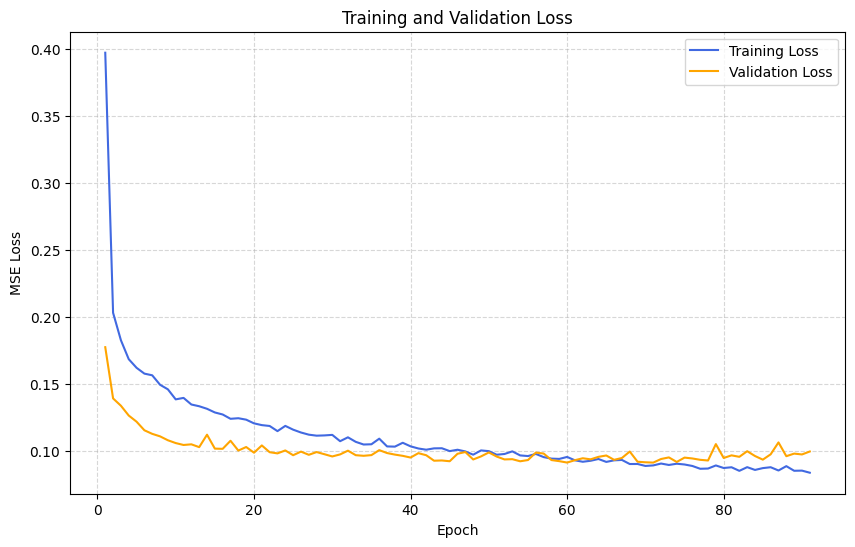

In [38]:
plot_loss(train_losses, val_losses)

In [41]:
def plot_scatter(x_pred, y_pred, x_true, y_true):
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.scatter(x_true, x_pred, s=10, alpha=0.4, color='royalblue')
  min_val_x, max_val_x = np.min(x_true), np.max(x_true)
  plt.plot([min_val_x, max_val_x], [min_val_x, max_val_x], '--', color = 'midnightblue', label = 'Perfect prediction')
  plt.xlabel("True x")
  plt.ylabel("Predicted x")
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.legend()
  plt.subplot(1,2,2)
  plt.scatter(y_true, y_pred, s=10, alpha=0.4, color='limegreen')
  min_val_y, max_val_y = np.min(y_true), np.max(y_true)
  plt.plot([min_val_y, max_val_y], [min_val_y, max_val_y], '--', color = 'darkgreen', label = 'Perfect prediction')
  plt.xlabel("True y")
  plt.ylabel("Predicted y")
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.legend()
  plt.tight_layout()
  plt.show()

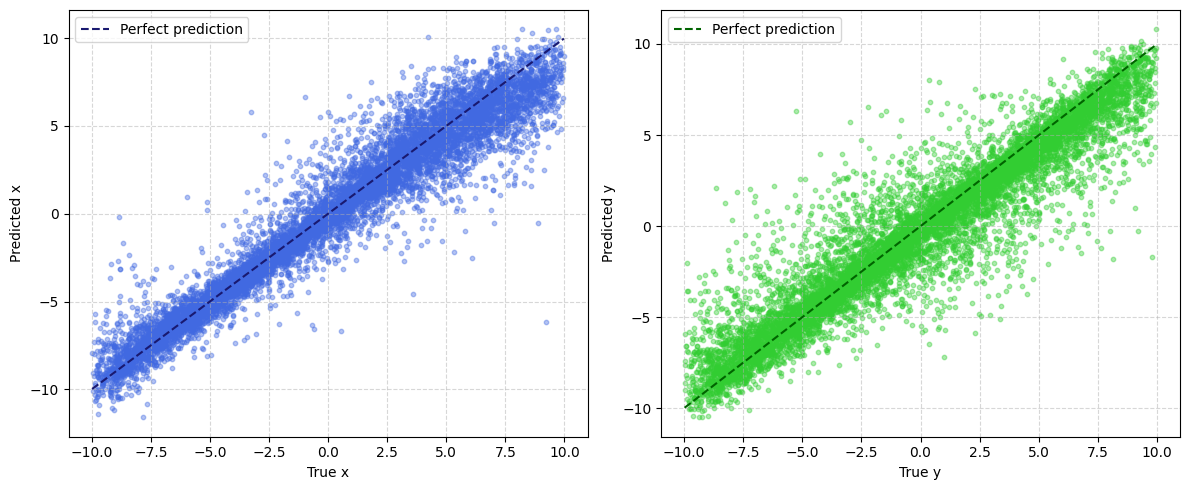

In [42]:
plot_scatter(pred_x_real, pred_y_real, target_x_real, target_y_real)

In [43]:
def plot_residuals(x_pred, y_pred, x_true, y_true):
  residuals_x = x_pred - x_true
  residuals_y = y_pred - y_true
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  plt.hist(residuals_x, bins=60, alpha=0.6, label='Residual on X', color='royalblue', edgecolor = 'royalblue')
  plt.axvline(0, color='midnightblue', linestyle='dashed', linewidth=1, label = 'Best prediciton')
  plt.xlabel('Residual (Predicted - Real) [m]')
  plt.ylabel('Counts')
  plt.legend()
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.subplot(1,2,2)
  plt.hist(residuals_y, bins=60, alpha=0.6, label='Residual on Y', color='limegreen', edgecolor = 'limegreen')
  plt.axvline(0, color='darkgreen', linestyle='dashed', linewidth=1, label = 'Best prediciton')
  plt.xlabel('Residual (Predicted - Real) [m]')
  plt.ylabel('Counts')
  plt.legend()
  plt.grid(True, alpha=0.5, linestyle='--')
  plt.tight_layout()
  plt.show()
  incertezza_global_x = np.std(residuals_x)
  incertezza_global_y = np.std(residuals_y)

  print(f"Global uncertainty on X: ± {incertezza_global_x:.2f} m")
  print(f"Global uncertainty on Y: ± {incertezza_global_y:.2f} m")

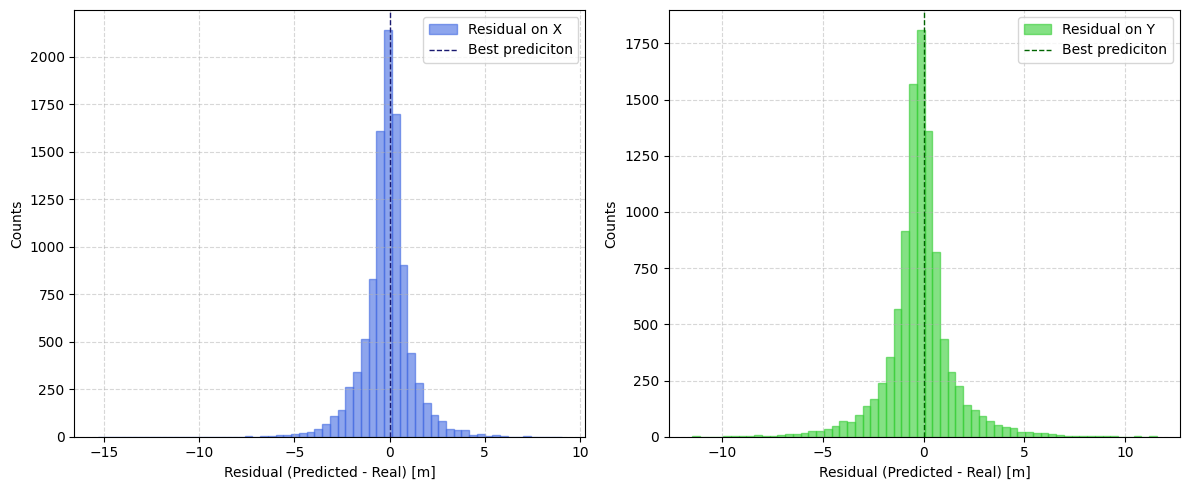

Global uncertainty on X: ± 1.29 m
Global uncertainty on Y: ± 1.65 m


In [44]:
plot_residuals(pred_x_real, pred_y_real, target_x_real, target_y_real)

# **2. Feature and uncertainty prediction with a GNN**

In [45]:
model2 = GNNEncoder(in_features=3, hidden_dim=64, out_features=4, k=15).to(device)

In [46]:
def nnl_loss(predictions, labels, n_labels):
  mean = predictions[:, :n_labels]
  log_std = predictions[:, n_labels:]
  std = torch.exp(log_std)
  return torch.mean(0.5 * ((labels - mean) / std )**2 + log_std)

In [47]:
import copy
def train_model_gnn_probabilistic(model, train_loader, val_loader, epochs, lr, patience, device, loss_function, model_name="gnn_prob"):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for step, (packed_data, batch_labels) in enumerate(train_loader):
            packed_data, batch_labels = packed_data.to(device), batch_labels.to(device)
            optimizer.zero_grad()

            # Output has dim [Batch, 4]
            outputs = model(packed_data)

            # Negative log-likelihood for loss
            loss = loss_function(outputs, batch_labels, batch_labels.shape[1])

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # --- VALIDATION PHASE ---
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for packed_data, batch_labels in val_loader:
                packed_data, batch_labels = packed_data.to(device), batch_labels.to(device)
                outputs = model(packed_data)

                val_loss = loss_function(outputs, batch_labels, batch_labels.shape[1])
                total_val_loss += val_loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss (GNLL): {avg_train_loss:.4f}, Val Loss (GNLL): {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break

    if best_model is not None:
        model.load_state_dict(best_model)
    return train_losses, val_losses, model

In [48]:
def evaluate_model_gnn_probabilistic(model, test_loader, device, loss_function):

    print("Evaluating model...")

    model.eval()
    all_means = []
    all_sigmas = []
    all_true_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for packed_data, batch_labels in test_loader:
            packed_data = packed_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(packed_data)

            means = outputs[:, :2]
            log_std = outputs[:, 2:]
            std = torch.exp(log_std)

            loss = loss_function(outputs, batch_labels, batch_labels.shape[1])
            total_loss += loss.item()

            all_means.append(means.cpu())
            all_sigmas.append(std.cpu())
            all_true_labels.append(batch_labels.cpu())

    preds_np = torch.cat(all_means, dim=0).numpy()
    sigmas_np = torch.cat(all_sigmas, dim=0).numpy()
    targets_np = torch.cat(all_true_labels, dim=0).numpy()

    avg_test_loss = total_loss / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")

    return preds_np, sigmas_np, targets_np

In [49]:
train_losses_2, val_losses_2, best_model_2 = train_model_gnn_probabilistic(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    lr = learning_rate,
    patience=patience,
    device=device,
    loss_function = nnl_loss,
    model_name="gnn_prob"
)

Epoch [1/100], Train Loss (GNLL): 0.1424, Val Loss (GNLL): -0.1634
Epoch [2/100], Train Loss (GNLL): -0.2282, Val Loss (GNLL): -0.4696
Epoch [3/100], Train Loss (GNLL): -0.3972, Val Loss (GNLL): -0.6023
Epoch [4/100], Train Loss (GNLL): -0.4759, Val Loss (GNLL): -0.6687
Epoch [5/100], Train Loss (GNLL): -0.5290, Val Loss (GNLL): -0.7414
Epoch [6/100], Train Loss (GNLL): -0.5652, Val Loss (GNLL): -0.7504
Epoch [7/100], Train Loss (GNLL): -0.5844, Val Loss (GNLL): -0.7498
Epoch [8/100], Train Loss (GNLL): -0.6219, Val Loss (GNLL): -0.7916
Epoch [9/100], Train Loss (GNLL): -0.6440, Val Loss (GNLL): -0.8156
Epoch [10/100], Train Loss (GNLL): -0.6632, Val Loss (GNLL): -0.8540
Epoch [11/100], Train Loss (GNLL): -0.6911, Val Loss (GNLL): -0.8549
Epoch [12/100], Train Loss (GNLL): -0.6854, Val Loss (GNLL): -0.8456
Epoch [13/100], Train Loss (GNLL): -0.6925, Val Loss (GNLL): -0.8586
Epoch [14/100], Train Loss (GNLL): -0.6934, Val Loss (GNLL): -0.8170
Epoch [15/100], Train Loss (GNLL): -0.7144, 

In [50]:
preds_np_2, sigmas_np_2, targets_np_2 = evaluate_model_gnn_probabilistic(
    model=best_model_2,
    test_loader=test_loader,
    device=device,
    loss_function=nnl_loss
)

Evaluating model...
Final Test Loss: -1.0828


# **DENORMALIZING**

In [51]:
pred_x_real2 = preds_np_2[:, 0] * x_std_orig + x_mean_orig
pred_y_real = preds_np_2[:, 1] * y_std_orig + y_mean_orig

target_x_real2 = targets_np_2[:, 0] * x_std_orig +  x_mean_orig
target_y_real2 = targets_np_2[:, 1] * y_std_orig + y_mean_orig

sigma_x_real2 = sigmas_np_2[:, 0] * x_std_orig
sigma_y_real2 = sigmas_np_2[:, 1] * y_std_orig

# **PLOTTING**

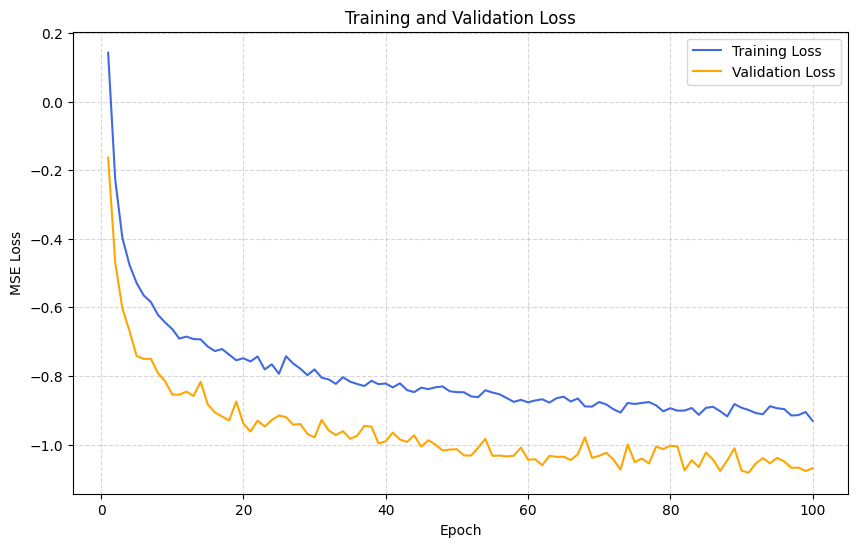

In [52]:
plot_loss(train_losses_2, val_losses_2)

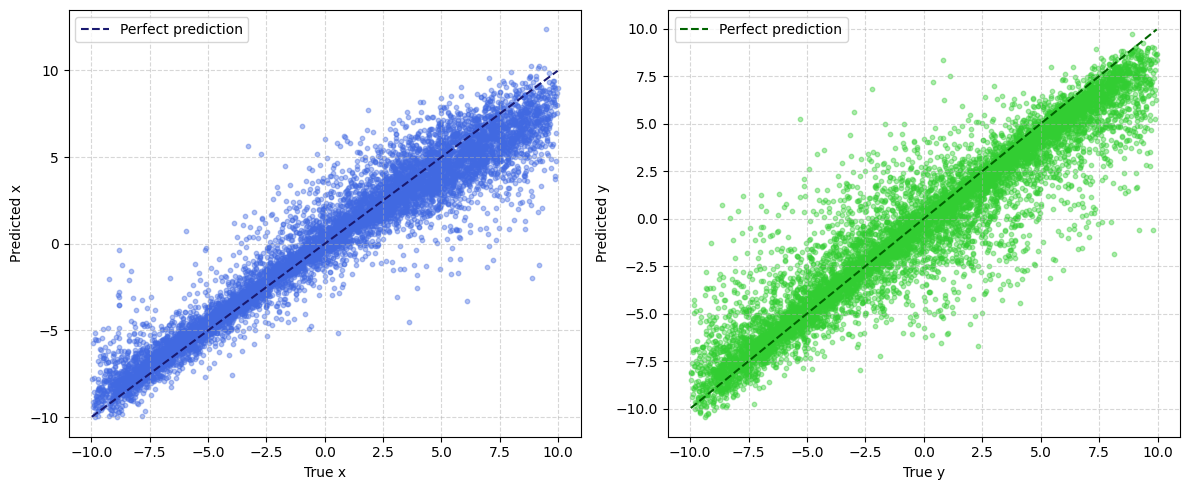

In [53]:
plot_scatter(pred_x_real2, pred_y_real, target_x_real2, target_y_real2)

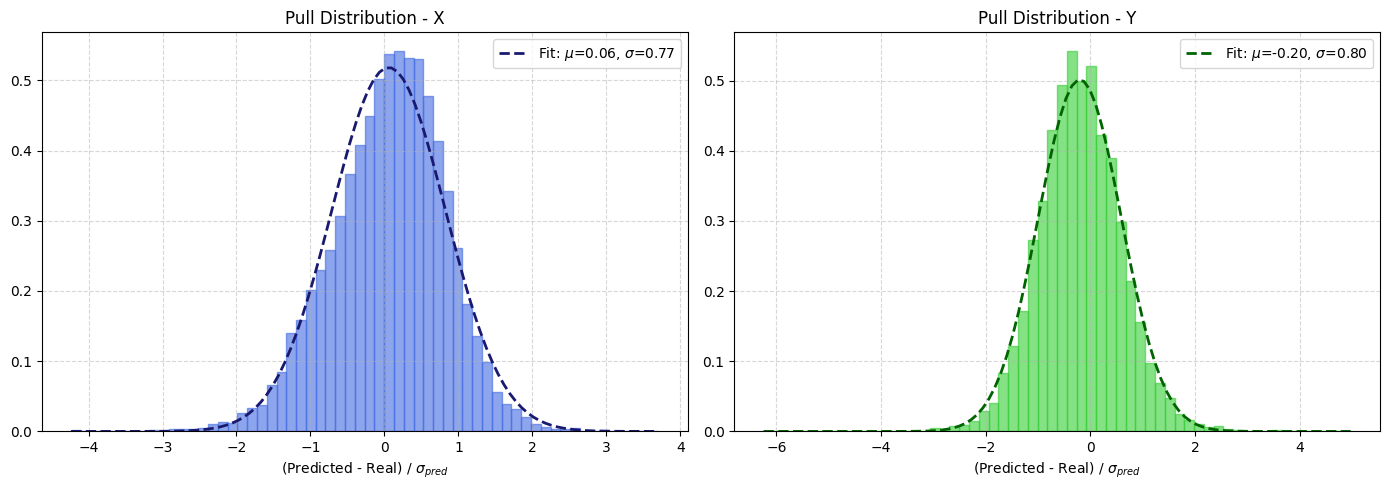

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

pull_x = (pred_x_real2 - target_x_real2) / sigma_x_real2
pull_y = (pred_y_real - target_y_real2) / sigma_y_real2

plt.figure(figsize=(14, 5))

# --- Plot X ---
plt.subplot(1, 2, 1)
plt.hist(pull_x, bins=60, density=True, alpha=0.6, color='royalblue', edgecolor='royalblue')

(mu_x, sigma_x) = stats.norm.fit(pull_x)
x_linspace = np.linspace(pull_x.min(), pull_x.max(), 100)

plt.plot(x_linspace, stats.norm.pdf(x_linspace, mu_x, sigma_x), '--', linewidth=2, color='midnightblue',
         label=rf'Fit: $\mu$={mu_x:.2f}, $\sigma$={sigma_x:.2f}')

plt.title('Pull Distribution - X')

plt.xlabel(r'(Predicted - Real) / $\sigma_{pred}$')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')

# --- Plot Asse Y ---
plt.subplot(1, 2, 2)
plt.hist(pull_y, bins=60, density=True, alpha=0.6, color='limegreen', edgecolor='limegreen')

# Fit e Plot Y
(mu_y, sigma_y) = stats.norm.fit(pull_y)
y_linspace = np.linspace(pull_y.min(), pull_y.max(), 100)

plt.plot(y_linspace, stats.norm.pdf(y_linspace, mu_y, sigma_y), '--', linewidth=2, color='darkgreen',
         label=rf'Fit: $\mu$={mu_y:.2f}, $\sigma$={sigma_y:.2f}')

plt.title('Pull Distribution - Y')
plt.xlabel(r'(Predicted - Real) / $\sigma_{pred}$')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

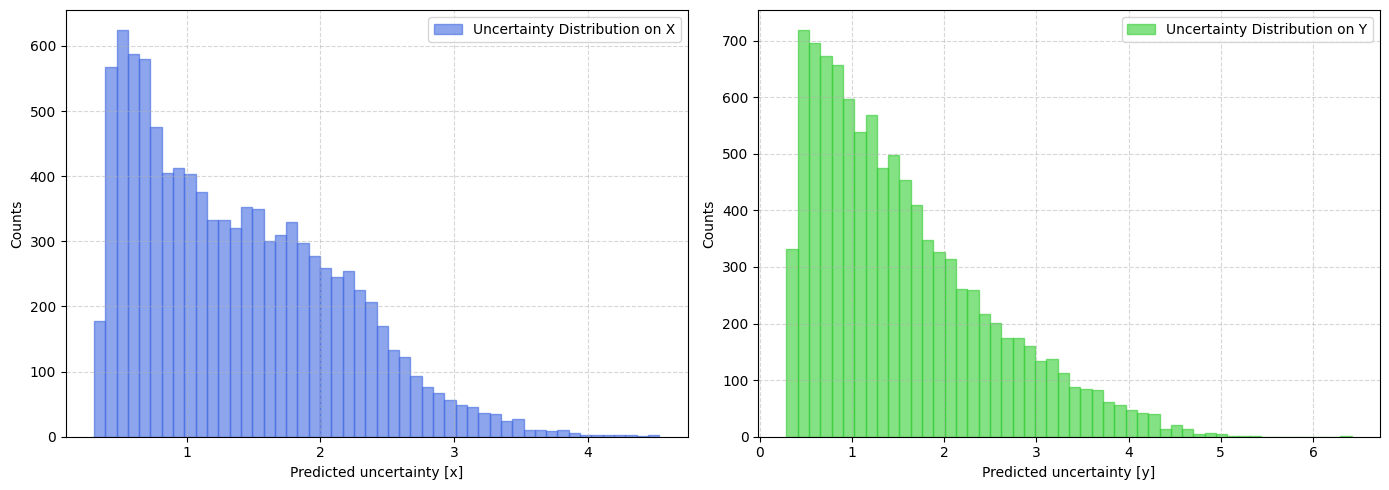

In [57]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(sigma_x_real2, bins=50, color='royalblue', edgecolor='royalblue', alpha=0.6, label='Uncertainty Distribution on X')
plt.xlabel(f'Predicted uncertainty [x]')
plt.ylabel('Counts')
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(sigma_y_real2, bins=50, color='limegreen', edgecolor='limegreen', alpha=0.6, label='Uncertainty Distribution on Y')
plt.xlabel(f'Predicted uncertainty [y]')
plt.ylabel('Counts')
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

# **3. UNCERTAINTY PREDICTION WITH NORMALIZING FLOW**

In [58]:
!pip install git+https://github.com/thoglu/jammy_flows.git --no-deps

  Cloning https://github.com/thoglu/jammy_flows.git to /tmp/pip-req-build-cqd__ayx
  Running command git clone --filter=blob:none --quiet https://github.com/thoglu/jammy_flows.git /tmp/pip-req-build-cqd__ayx
  Resolved https://github.com/thoglu/jammy_flows.git to commit 3ec7872f8535b8e8db2e31f74a7c55bad5c54d5f
  Preparing metadata (setup.py) ... done
  Created wheel for jammy_flows: filename=jammy_flows-1.0.0-py3-none-any.whl size=174322 sha256=b9311b1a7a555a41621968de1642b69e31171274d6f3a2ee8a24ae1123b2828a
  Stored in directory: /tmp/pip-ephem-wheel-cache-pxy2sxss/wheels/c0/ce/35/60016f460c07fecc64f55db2a40862c9add349fb0620845532
Successfully built jammy_flows


In [101]:
import jammy_flows
from scipy.stats import norm

In [60]:
def nf_loss(model, features, labels):
  log_pdfs = model.log_pdf_evaluation(labels, features) # get the probability of the labels given the input data
  loss = -log_pdfs.mean() # take the negative mean of the log probabilities
  return loss

In [72]:
def train_model_nf(model, train_loader, val_loader, learning_rate, num_epochs, patience,
                device, plot_fn=None, plot_interval=10, plot_kwargs=None, model_name=None):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model = None

    for epoch in range(num_epochs):
        start_time = time.time()  # Start the timer for this epoch

        # Training phase
        model.train()
        total_train_loss = 0.0
        for step, (batch_spectra, batch_labels) in enumerate(train_loader):
            batch_spectra, batch_labels = batch_spectra.to(device), batch_labels.to(device)  # Add channel dimension for CNNs

            optimizer.zero_grad()

            loss = nf_loss(model, batch_spectra, batch_labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            # Print progress every 10th step, updating the same line
            if (step + 1) % 10 == 0:
                sys.stdout.write(f"\rEpoch [{epoch + 1}/{num_epochs}], Step [{step + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
                sys.stdout.flush()

        sys.stdout.write("\n")  # Move to the next line after the epoch

        # Validation phase
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for batch_spectra, batch_labels in val_loader:
                batch_spectra, batch_labels = batch_spectra.to(device), batch_labels.to(device)

                val_loss = nf_loss(model, batch_spectra, batch_labels)

                total_val_loss += val_loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Store losses for plotting
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Print epoch summary
        epoch_time = time.time() - start_time  # Calculate epoch time
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_time:.2f} seconds")

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model = copy.copy(model.state_dict())
            # Save the best model to the "models" directory
            if not os.path.exists('models'):
                os.makedirs('models')
            if model_name is not None:
                torch.save(best_model, f"models/{model_name}_best.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        if(epoch%plot_interval==0):
            if(plot_fn is not None):

                assert(plot_kwargs is not None)

                assert("test_loader" in plot_kwargs.keys())
                assert("ranges" in plot_kwargs.keys())
                assert("plot_folder" in plot_kwargs.keys())

                plot_fn(model,
                        plot_kwargs["test_loader"],
                        nf_loss,
                        device,
                        plot_kwargs["ranges"],
                        train_losses,
                        val_losses,
                        plot_folder=plot_kwargs["plot_folder"],
                        suffix="epoch_%.5d" % epoch)

    return train_losses, val_losses, best_model

In [73]:
def evaluate_model(model, test_loader, device, samplesize=1000):

    print("Evaluating Normalizing Flow model on the test dataset...")
    model.eval()
    total_test_nll = 0.0

    all_predictions = []
    all_uncertainties = []
    all_true_labels = []

    first_batch_spectra=None
    first_batch_labels=None

    with torch.no_grad():
        for batch_index, (batch_spectra, batch_labels) in enumerate(test_loader):
            batch_spectra, batch_labels = batch_spectra.to(device), batch_labels.to(device)

            # Apply loss function
            total_test_nll += nf_loss(model, batch_spectra, batch_labels).item()

            outputs = model(batch_spectra, samplesize_per_batchitem=samplesize)

            n = batch_labels.shape[1]
            means = outputs[:, :n]
            stds = outputs[:, n:]

            all_predictions.append(means.cpu())
            all_uncertainties.append(stds.cpu())
            all_true_labels.append(batch_labels.cpu())

            if(batch_index==0):
                first_batch_spectra=batch_spectra
                first_batch_labels=batch_labels

    avg_test_loss = total_test_nll / len(test_loader)
    print(f"Final Test Loss: {avg_test_loss:.4f}")
    return torch.cat(all_predictions).numpy(), torch.cat(all_uncertainties).numpy(), torch.cat(all_true_labels).numpy(), first_batch_spectra, first_batch_labels

In [74]:
fp64_on_cpu = False

In [102]:
class NormFlow(nn.Module):

    def __init__(self, encoder, nf_type="diagonal_gaussian"):
        super().__init__()
        # we define a 3-d PDF over Euclidean spae (e3)
        # using recommended settings (https://github.com/thoglu/jammy_flows/issues/5 scroll down)
        opt_dict = {}
        opt_dict["t"] = {}
        if (nf_type == "diagonal_gaussian"):
                opt_dict["t"]["cov_type"] = "diagonal"
                flow_defs = "t"
        elif (nf_type == "full_gaussian"):
                opt_dict["t"]["cov_type"] = "full"
                flow_defs = "t"
        elif (nf_type == "full_flow"):
                opt_dict["t"]["cov_type"] = "full"
                flow_defs = "gggt"
        else:
                raise Exception("Unknown nf type ", nf_type)

        opt_dict["g"] = dict()
        opt_dict["g"]["fit_normalization"] = 1
        opt_dict["g"]["upper_bound_for_widths"] = 1.0
        opt_dict["g"]["lower_bound_for_widths"] = 0.01

        self.nf_type = nf_type

        # 3d PDF (e3) with ggggt flow structure. Four Gaussianation-flow (https://arxiv.org/abs/2003.01941) layers ("g") and an affine flow ("t")
        self.pdf = jammy_flows.pdf("e2", flow_defs, options_overwrite=opt_dict,
                                amortize_everything=True, amortization_mlp_use_custom_mode=True)

        # get the number of flow parameters
        num_flow_parameters = self.pdf.total_number_amortizable_params

        print("The normalizing flow has ", num_flow_parameters, " parameters...")

        self.encoder = encoder(3, 64, num_flow_parameters, 15)

    def log_pdf_evaluation(self, target_labels, input_data):

        latent_intermediate = self.encoder(input_data)  # get the flow parameters from the CNN encoder

        if (self.nf_type == "full_flow"):
                # convert to double. Double precision is needed for the Gaussianization flow. This is for numerical stability.
                if fp64_on_cpu:  # MPS does not support double precision, therefore we need to run the flow on the CPU
                        latent_intermediate = latent_intermediate.cpu().to(torch.float64)
                        target_labels = target_labels.cpu().to(torch.float64)
                else:
                        latent_intermediate = latent_intermediate.to(torch.float64)
                        target_labels = target_labels.to(torch.float64)

        # evaluate the log PDF at the target labels
        log_pdf, _, _ = self.pdf(target_labels, amortization_parameters=latent_intermediate)
        return log_pdf

    def sample(self, flow_params, samplesize_per_batchitem=1000):

        # for full flow we need to convert to double precision for the normalizing flow
        # for numerical stability
        if (self.nf_type == "full_flow"):
                # convert to double
                if fp64_on_cpu: # MPS does not support double precision, therefore we need to run the flow on the CPU
                        flow_params = flow_params.cpu().to(torch.float64)
                else:
                        flow_params = flow_params.to(torch.float64)

        batch_size = flow_params.shape[0] # get the batch size
        # sample from the normalizing flow
        repeated_samples, _, _, _ = self.pdf.sample(amortization_parameters=flow_params.repeat_interleave(
                samplesize_per_batchitem, dim=0), allow_gradients=False)

        # reshape the samples to be grouped by batch item
        reshaped_samples = repeated_samples[:, None, :].view(
                batch_size, samplesize_per_batchitem, -1)

        return reshaped_samples

    def forward(self, input_data, samplesize_per_batchitem=1000):

        flow_params=self.encoder(input_data)
        samples=self.sample(flow_params, samplesize_per_batchitem=samplesize_per_batchitem)

        # form mean along dim 1 (samples)
        means=samples.mean(dim=1)
        # form std along dim 1 (samples)
        std_deviations=samples.std(dim=1)

        # return means and std deviations as a concatenated tensor along dim 1
        return torch.cat([means, std_deviations], dim=1)

    def visualize_pdf(self, input_data, filename, samplesize=1000, batch_index=0, truth=None):

        #Divide the disconnected graph of a batch into graphs for single events and select one of them
        single_graph = input_data.to_data_list()[batch_index]
        #The encoder takes a Batch object (graph + list of indices that associate each node to each single graph): from the graph for one event we recreate a batch
        #(in this case containing a single event)
        input_bitem = Batch.from_data_list([single_graph]).to(single_graph.x.device)

        flow_params = self.encoder(input_bitem)

        # sample from the normalizing flow
        samples = self.sample(flow_params, samplesize_per_batchitem=samplesize)

        # we only have 1 batch item
        samples = samples.squeeze(0)

        # plot three 1-dimensional distributions together with normal approximation,
        mean = samples.mean(dim=0).cpu().numpy()
        std = samples.std(dim=0).cpu().numpy()
        samples = samples.cpu().numpy()

        fig, axdict = plt.subplots(2, 1, figsize = (10,10))
        for dim_ind in range(2):
            # plot the histogram of the samples
            axdict[dim_ind].hist(samples[:, dim_ind], color="k", density=True,
                                 bins=50, alpha=0.5, label="density based on samples")

            # plot the Gaussian approximation
            min_sample = samples[:, dim_ind].min()
            max_sample = samples[:, dim_ind].max()
            xvals = np.linspace(min_sample, max_sample, 1000)
            yvals = norm.pdf(xvals, loc=mean[dim_ind], scale=std[dim_ind])
            axdict[dim_ind].plot(xvals, yvals, color="green",
                                 label="Gaussian approximation")
            # plot the true value if it is given
            if (truth is not None):
                true_value = truth[dim_ind].item() if hasattr(truth[dim_ind], 'item') else truth[dim_ind]
                axdict[dim_ind].axvline(
                    true_value, color="red", label="true value")

            # plot the legend only for the first panel
            if (dim_ind == 0):
                axdict[dim_ind].legend()

        plt.savefig(filename)
        plt.close(fig)

In [103]:
model_choice = 'full_flow'

# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

model = NormFlow(encoder=GNNEncoder, nf_type=model_choice).to(device)

Using device: cuda
The normalizing flow has  197  parameters...


In [81]:
train_losses_full_g, val_losses_full_g, best_model_state_full_g = train_model_nf(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    learning_rate=learning_rate,
    num_epochs=num_epochs,
    patience=patience,
    device=device,
    model_name=model_choice
)

model.load_state_dict(best_model_state_full_g)

preds_norm_full_g, stds_norm_full_g, true_norm_full_g, first_spec_full_g, first_lab_full_g = evaluate_model(
    model,
    test_loader,
    device,
    samplesize=1000
)

Using device: cuda
The normalizing flow has  197  parameters...
Epoch [1/100], Step [150/157], Loss: 1.7790
Epoch [1/100], Train Loss: 3.2213, Val Loss: 1.7032, Time: 24.70 seconds
Epoch [2/100], Step [150/157], Loss: 1.6664
Epoch [2/100], Train Loss: 1.8511, Val Loss: 1.2567, Time: 24.31 seconds
Epoch [3/100], Step [150/157], Loss: 1.4936
Epoch [3/100], Train Loss: 1.5037, Val Loss: 0.9067, Time: 24.25 seconds
Epoch [4/100], Step [150/157], Loss: 1.1918
Epoch [4/100], Train Loss: 1.2682, Val Loss: 0.7158, Time: 24.33 seconds
Epoch [5/100], Step [150/157], Loss: 1.4146
Epoch [5/100], Train Loss: 1.1177, Val Loss: 0.6224, Time: 23.31 seconds
Epoch [6/100], Step [150/157], Loss: 0.9996
Epoch [6/100], Train Loss: 1.0359, Val Loss: 0.4857, Time: 24.74 seconds
Epoch [7/100], Step [150/157], Loss: 1.2895
Epoch [7/100], Train Loss: 0.9563, Val Loss: 0.4248, Time: 24.77 seconds
Epoch [8/100], Step [150/157], Loss: 0.8752
Epoch [8/100], Train Loss: 0.8960, Val Loss: 0.3501, Time: 23.50 seconds


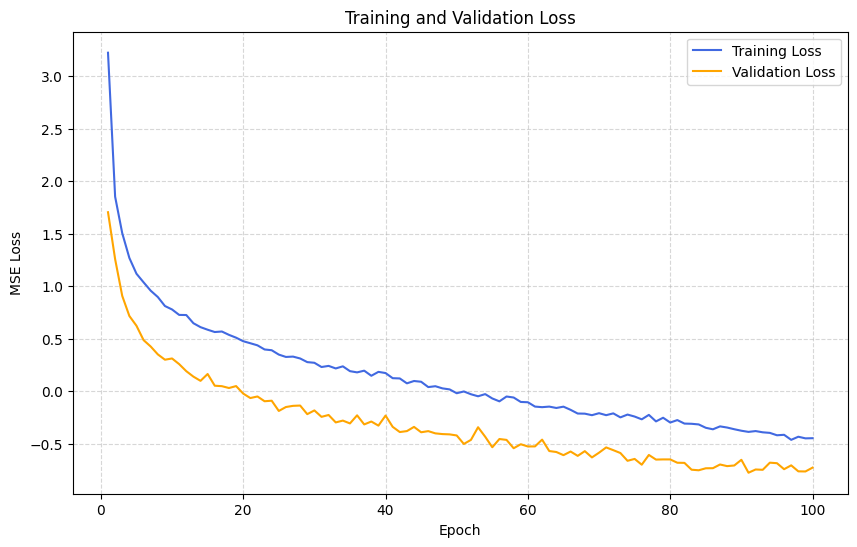

In [83]:
plot_loss(train_losses_full_g, val_losses_full_g)

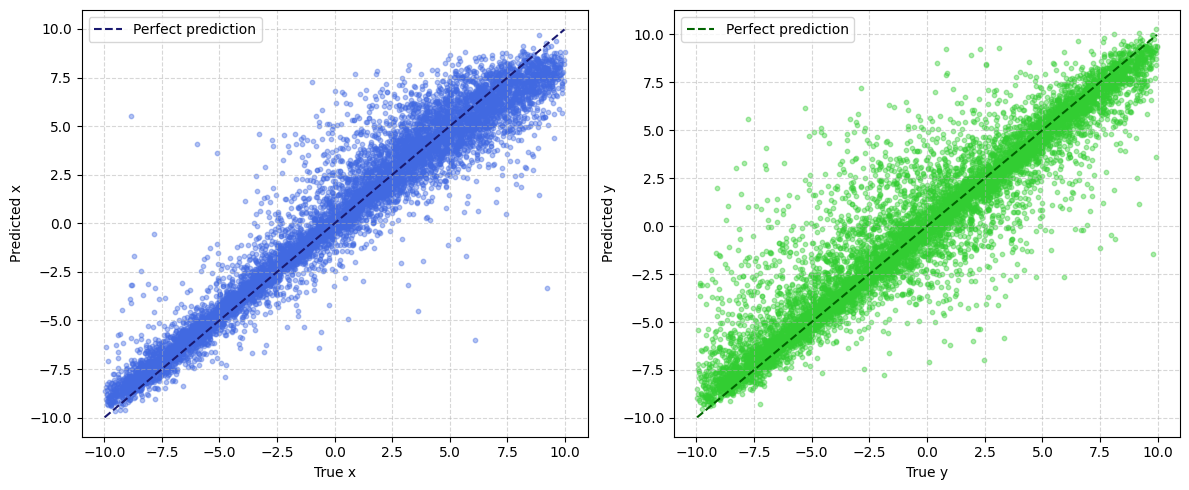

In [85]:
pred_x_real3 = preds_norm_full_g[:, 0] * x_std_orig + x_mean_orig
pred_y_real3 = preds_norm_full_g[:, 1] * y_std_orig + y_mean_orig

target_x_real3 = true_norm_full_g[:, 0] * x_std_orig +  x_mean_orig
target_y_real3 = true_norm_full_g[:, 1] * y_std_orig + y_mean_orig

sigma_x_real3 = stds_norm_full_g[:, 0] * x_std_orig
sigma_y_real3 = stds_norm_full_g[:, 1] * y_std_orig

plot_scatter(pred_x_real3, pred_y_real3, target_x_real3, target_y_real3)

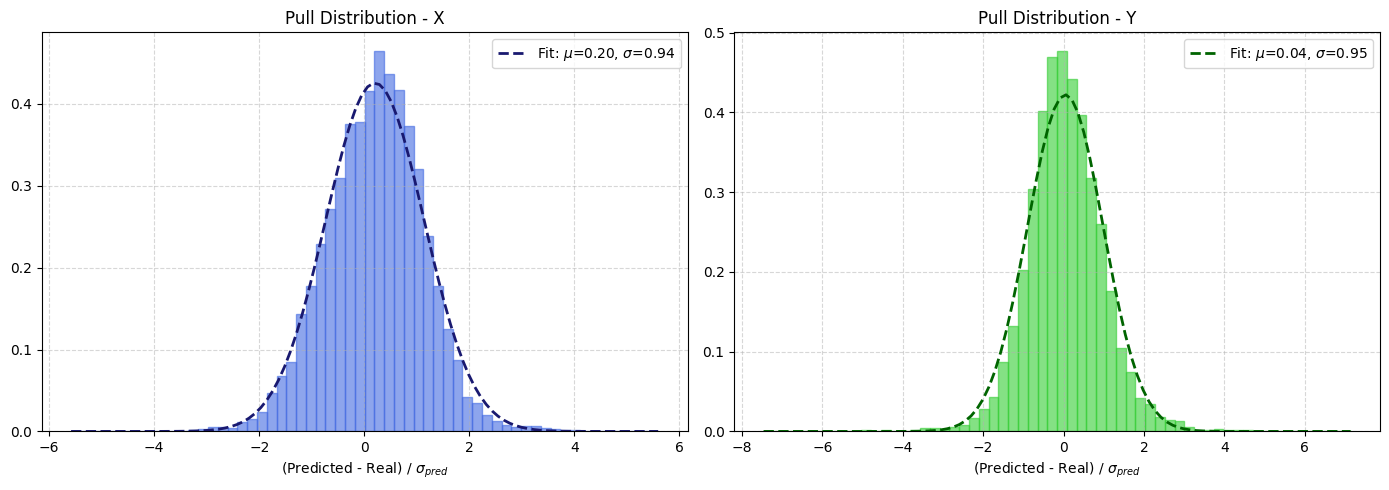

In [86]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

pull_x = (pred_x_real3 - target_x_real3) / sigma_x_real3
pull_y = (pred_y_real3 - target_y_real3) / sigma_y_real3

plt.figure(figsize=(14, 5))

# --- Plot X ---
plt.subplot(1, 2, 1)
plt.hist(pull_x, bins=60, density=True, alpha=0.6, color='royalblue', edgecolor='royalblue')

(mu_x, sigma_x) = stats.norm.fit(pull_x)
x_linspace = np.linspace(pull_x.min(), pull_x.max(), 100)

plt.plot(x_linspace, stats.norm.pdf(x_linspace, mu_x, sigma_x), '--', linewidth=2, color='midnightblue',
         label=rf'Fit: $\mu$={mu_x:.2f}, $\sigma$={sigma_x:.2f}')

plt.title('Pull Distribution - X')

plt.xlabel(r'(Predicted - Real) / $\sigma_{pred}$')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')

# --- Plot Asse Y ---
plt.subplot(1, 2, 2)
plt.hist(pull_y, bins=60, density=True, alpha=0.6, color='limegreen', edgecolor='limegreen')

# Fit e Plot Y
(mu_y, sigma_y) = stats.norm.fit(pull_y)
y_linspace = np.linspace(pull_y.min(), pull_y.max(), 100)

plt.plot(y_linspace, stats.norm.pdf(y_linspace, mu_y, sigma_y), '--', linewidth=2, color='darkgreen',
         label=rf'Fit: $\mu$={mu_y:.2f}, $\sigma$={sigma_y:.2f}')

plt.title('Pull Distribution - Y')
plt.xlabel(r'(Predicted - Real) / $\sigma_{pred}$')
plt.legend()
plt.grid(True, alpha=0.5, linestyle='--')
plt.tight_layout()
plt.show()

In [106]:
#visualizing pdfs such that before visualizing the model switches to evaluation mode so that you don't have to run the whole training again.
original_training_state = model.training
model.eval()

try:
    model.visualize_pdf(first_spec_full_g, truth=first_lab_full_g[0], filename='prova')
finally:
    if original_training_state:
        model.train()
    else:
        model.eval()

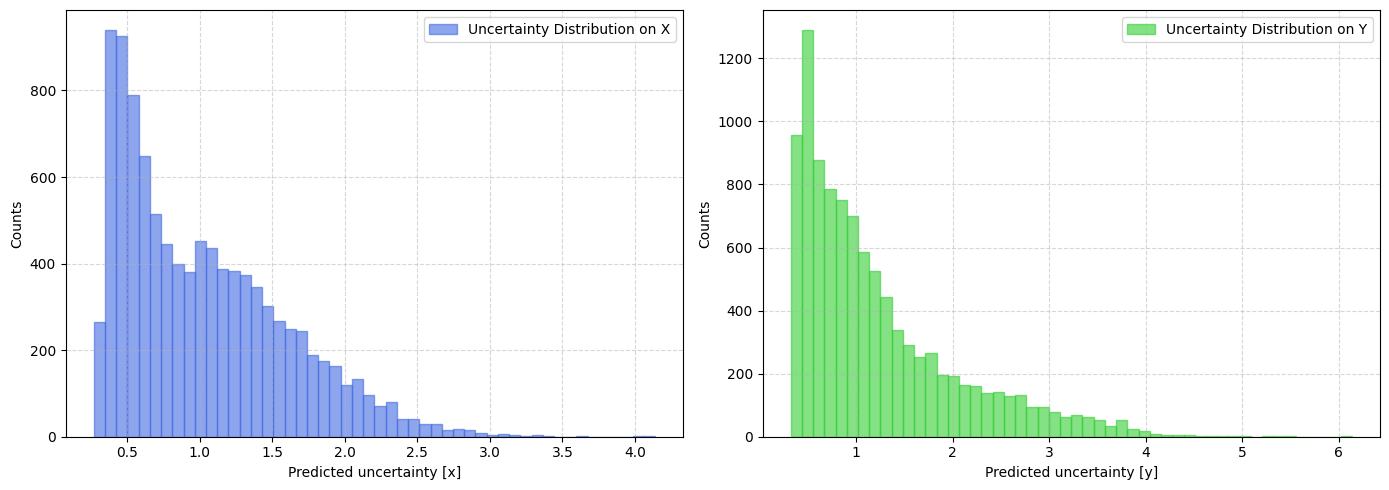

In [107]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.hist(sigma_x_real3, bins=50, color='royalblue', edgecolor='royalblue', alpha=0.6, label='Uncertainty Distribution on X')
plt.xlabel(f'Predicted uncertainty [x]')
plt.ylabel('Counts')
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(sigma_y_real3, bins=50, color='limegreen', edgecolor='limegreen', alpha=0.6, label='Uncertainty Distribution on Y')
plt.xlabel(f'Predicted uncertainty [y]')
plt.ylabel('Counts')
plt.grid(True, alpha=0.5, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()